In [1]:
%matplotlib widget
import ipywidgets as widgets

import os
import time
# import yaml
import numpy as np
from sciform import Formatter
# from scipy.stats import norm
# from scipy.stats import tstd
# from scipy import signal
# from statsmodels.stats.weightstats import DescrStatsW
import scared
from scared import aes
from scared.aes.selection_functions.encrypt import _add_round_key, _last_key
from pathlib import Path
import estraces
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO

from pathlib import Path
from PIL import Image

import data_url
from PIL.PngImagePlugin import PngInfo
import requests

In [2]:
SAVE_PLOTS = False
DEBUG = True
Ts= 5e9
fs = 1/Ts

In [3]:
def ask_for_int(prompt, *, min_value=None, max_value=None):
    while True:
        user_input = input(prompt)

        try:
            value = int(user_input)
        except ValueError:
            print("Please enter a valid integer.")
            continue

        if min_value is not None and value < min_value:
            print(f"Please enter a value greater than or equal to {min_value}.")
            continue

        if max_value is not None and value > max_value:
            print(f"Please enter a value less than or equal to {max_value}.")
            continue

        return value

def ask_yes_no(prompt: str) -> bool:
    while True:
        response = input(f"{prompt} [y/n]: ").strip().lower()

        if response in ("y", "yes"):
            return True

        if response in ("n", "no"):
            return False

        print("Please enter 'y' or 'n'.")

In [4]:
sform = Formatter(
    exp_mode="engineering",
    exp_format="prefix",     # uses e.g. M instead of e+06
    round_mode="dec_place",  # or "sig_fig" if we want to specify the total number of digits
    ndigits=3
)

In [5]:
# Ask student for image URL
def get_image_from_url(image_url):

    # Download image
    response = requests.get(image_url)
    response.raise_for_status()

    # Open image and force 3-channel RGB
    img = Image.open(BytesIO(response.content)).convert("RGB")

    # Optional: resize to keep encryption/decryption manageable
    img = img.resize((256, 256))

    # Convert to 256 x 256 x 3 NumPy array
    img_array = np.asarray(img, dtype=np.uint8)
    return img_array

def render_image(img_array):
    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array)
    plt.axis("off")
    plt.show()

def dpac_get_keys():
    key_strs = [
        "0000000000000003243F6A8885A308D3",
        "082EFA98EC4E6C89452821E638D01377",
        "0D95748F728EB658718BCD5882154AEE",
        "13198A2E03707344A4093822299F31D0",
        "21C66842F6E96C9A670C9C61ABD388F0",
        "23893E81D396ACC50F6D6FF383F44239",
        "24A19947B3916CF70801F2E2858EFC16",
        "2BA9C55D741831F6CE5C3E169B87931E",
        "2E0B4482A484200469C8F04A9E1F9B5E",
        "37D0D724D00A1248DB0FEAD349F1C09B",
        "3B8F48986B4BB9AFC4BFE81B66282193",
        "3F84D5B5B54709179216D5D98979FB1B",
        "4ED3AA62363F77061BFEDF72429B023D",
        "55CA396A2AAB10B6B4CC5C341141E8CE",
        "61D809CCFB21A991487CAC605DEC8032",
        "636920D871574E69A458FEA3F4933D7E",
        "6A51A0D2D8542F68960FA728AB5133A3",
        "6EEF0B6C137A3BE4BA3BF0507EFB2A98",
        "7B54A41DC25A59B59C30D5392AF26013",
        "8CEE8619456F9FB47D84A5C33B8B5EBE",
        "8E79DCB0603A180E6C9E0E8BB01E8A3E",
        "A15486AF7C72E993B3EE1411636FBC2A",
        "A1F1651D39AF017666CA593E82430E88",
        "AFD6BA336C24CF5C7A32538128958677",
        "B8E1AFED6A267E96BA7C9045F12C7F99",
        "BE5466CF34E90C6CC0AC29B7C97C50DD",
        "C5D1B023286085F0CA417918B8DB38EF",
        "D1310BA698DFB5AC2FFD72DBD01ADFB7",
        "D71577C1BD314B2778AF2FDA55605C60",
        "E06F75D885C12073401A449F56C16AA6",
        "E65525F3AA55AB945748986263E81440",
        "EF845D5DE98575B1DC262302EB651B88",
    ]

    return key_strs

def encrypt_image(img_array, key_num, DEBUG=False):
    key_strs = dpac_get_keys()

    # This is where students will input the key number, 1 through 32, which they want to use
    key_idx = key_num-1    # key_idx is zero indexed
    key = np.frombuffer(bytes.fromhex(key_strs[key_idx]), dtype=np.uint8)

    orig_shape = img_array.shape

    # Flatten image to 1D bytes
    img_flat = img_array.reshape(-1).astype(np.uint8)

    # Check AES block alignment
    if img_flat.size % 16 != 0:
        raise ValueError(f"Image byte length {img_flat.size} is not divisible by 16.")

    # Reshape into N x 16 AES blocks
    img_blocks = img_flat.reshape(-1, 16)

    # ---------------------------------------------------------
    # Placeholder for encryption step
    # encrypted_flat = encrypt_function(img_flat)
    # ---------------------------------------------------------
    # encrypted_blocks = img_blocks    # encrypted_blocks has shape (N, 16)
    encrypted_blocks = aes.encrypt(img_blocks, key)

    # Reshape the encrypted image blocks
    encrypted_flat = encrypted_blocks.reshape(-1)
    encrypted_img_array = encrypted_flat.reshape(orig_shape)

    # Create PNG metadata
    metadata = PngInfo()
    metadata.add_text("key_index", str(key_idx))

    # Save encrypted image with metadata
    encrypted_image_bytes = BytesIO()
    img_to_save = Image.fromarray(encrypted_img_array, mode="RGB")
    img_to_save.save(encrypted_image_bytes, format="png", pnginfo=metadata)

    if DEBUG:
        print(f"key shape:", key.shape)
        print(f"key dtype:", key.dtype)
        print(f"The key used to encrypt the image is 0x{key_strs[key_idx]}")
        print("Original image shape:", orig_shape)
        print("Original image dtype:", img_array.dtype)
        print("Flattened shape:", img_flat.shape)
        print("AES block array shape:", img_blocks.shape)
        print("AES block array dtype:", img_blocks.dtype)
        print("Encrypted image shape:", encrypted_img_array.shape)
        print("Encrypted image dtype:", encrypted_img_array.dtype)

    return encrypted_image_bytes

In [6]:
encrypted_image_file = Path("encrypted_images", "team_1_A_encrypted.png")

def load_encrypted_image(encrypted_image_file, DEBUG=False):
    encrypted_img = Image.open(encrypted_image_file, formats=["png"]).convert("RGB")
    encrypted_img_array = np.asarray(encrypted_img, dtype=np.uint8)

    # Read metadata to recover the key
    # TODO: catch if the metadata is not there
    key_idx = int(encrypted_img.info["key_index"])
    key_strs = dpac_get_keys()
    key = np.frombuffer(bytes.fromhex(key_strs[key_idx]), dtype=np.uint8)

    if DEBUG:
        print(f"key shape:", key.shape)
        print(f"key dtype:", key.dtype)
        print(f"The key used to encrypt the image is 0x{key_strs[key_idx]}")
        print("Loaded image shape:", encrypted_img_array.shape)
        print("Loaded image dtype:", encrypted_img_array.dtype)
        print("Key index:", key_idx)
    
    return encrypted_img_array, key_idx

def get_key(key_idx: int):
    key_strs = dpac_get_keys()
    key = np.frombuffer(bytes.fromhex(key_strs[key_idx]), dtype=np.uint8)
    return key

In [7]:
# this path will change when the demo is deployed
trace_dir = Path("./dpac")

def load_ths(key_idx: int):
    key_strs = dpac_get_keys()
    file_name = f"dpa_contest_{key_strs[key_idx]}.ets"
    ets_file = Path(trace_dir, file_name)   # appends the filename correctly
    ths = estraces.read_ths_from_ets_file(ets_file)
    if DEBUG:
        print(ths)
    return ths

In [8]:
# Display image
# plt.figure(figsize=(4, 4))
# plt.imshow(encrypted_img_array)
# plt.axis("off")
# plt.show()

In [9]:
def plot_traces(ths, num_traces, SAVE_PLOTS=False, DEBUG=False):
    t_pwr = Ts * np.arange(0, np.shape(ths.samples)[1])    # np.shape(ths_pwr.samples) = (num_traces, len_trace)
    t_pwr_us = t_pwr / 1e-6    # time series in µs

    P_fig, P_axs = plt.subplots(1, 1, figsize=(12,5), constrained_layout=True, sharex=False)  # Width=12 inches, Height=5 inches

    # either works
    # data = ths.samples[0:3]
    trace_inds = np.random.choice(np.shape(ths.samples)[0], num_traces, replace=False)
    data = ths[trace_inds].samples

    P_axs.set_xlabel('Time (µs)', fontsize=14)
    P_axs.set_ylabel('Switching Voltage Magnitude (mV)', fontsize=14)
    # plt.plot(data.T*1e-3/30)
    P_axs.plot(t_pwr_us, data.T*1e-3)
    P_axs.axvspan(t_pwr_us[450], t_pwr_us[650], facecolor=(0.8, 0.7, 0.2), label='First AES round')
    P_axs.axvspan(t_pwr_us[2340], t_pwr_us[2540], facecolor=(0.9, 0.4, 0.2), label='Last AES round')
    P_axs.set_title(f"{num_traces} Sample Power Traces for this Image")
    P_axs.tick_params(axis="both", labelsize=12)
    P_axs.legend()
    display(P_fig.canvas)

    if SAVE_PLOTS:
        fig_path = Path("images" , "spectral_analysis" , f"dpa_power_traces")
        # print(fig_path)
        P_fig.savefig(fig_path, dpi=300, bbox_inches="tight")

    if DEBUG:
        print(f"These traces are from key class {ths[0].key.tobytes().hex().upper()}")  # same as previous line
        print(f"The shape of data is {np.shape(data)}")
        print(f"The number of samples in each trace is {ths.samples.shape[1]}")

In [10]:
@scared.attack_selection_function
def first_round_subbytes_out(plaintext, guesses):
    res = np.empty((plaintext.shape[0], len(guesses), plaintext.shape[1]), dtype='uint8')
    for i, guess in enumerate(guesses):
        # r01_in = aes.add_round_key(plaintext, guess)
        r01_in = np.bitwise_xor(plaintext, guess)
        r01_sb_out = aes.sub_bytes(r01_in)
        # res[:, i, :] = np.bitwise_xor(r01_in, r01_sb_out)
        res[:, i, :] = r01_sb_out
    return res

@scared.attack_selection_function(expected_key_function=_last_key)
def delta_last_two_rounds(ciphertext, guesses):
    res = np.empty((ciphertext.shape[0], len(guesses), ciphertext.shape[1]), dtype='uint8')
    for i, guess in enumerate(guesses):
        s = aes.inv_sub_bytes(state=np.bitwise_xor(ciphertext, guess))
        res[:, i, :] = np.bitwise_xor(aes.shift_rows(ciphertext), s)
    return res

# query_string = "Which selection function would you like to use:\n"
# query_string = query_string + "first_round_subbytes_out (1)\n"
# query_string = query_string + "delta_last_two_rounds    (2)\n"

# sel_func_choice = ask_for_int(query_string, min_value=1, max_value=2)
# sel_choice_str = "chosen selection function for the attack is "
# if sel_func_choice == 1:
#     att_sel_func = first_round_subbytes_out
#     sel_choice_str = sel_choice_str + "first_round_subbytes_out"
# elif sel_func_choice == 2:
#     att_sel_func = delta_last_two_rounds
#     sel_choice_str = sel_choice_str + "delta_last_two_rounds"
# if DEBUG:
#     print(sel_choice_str)

In [11]:
# # Number of traces (for each key) to use for analysis (max value is 20_000)
# num_traces = ask_for_int("Choose the number of traces for the attack", min_value=1, max_value=20000)

# # This is hardcoded for now. We would only set these to something different
# # if we wanted to speed things up, in which case we would only select the
# # slice/frame associated with the round that corresponds to the selection
# # function chosen
# trace_win_min = 0
# trace_win_max = len(ths[0].samples)

# pwr_frame = slice(trace_win_min, trace_win_max)
# t_pwr_att = Ts*np.arange(pwr_frame.start, pwr_frame.stop)
# t_pwr_att_us = t_pwr_att / 1e-6    # time series in µs

In [26]:
def map_str_to_sel_fn(sel_fn_string):
    if sel_fn_string == "first_round_subbytes_out":
        return first_round_subbytes_out
    elif sel_fn_string == "delta_last_two_rounds":
        return delta_last_two_rounds


def get_expected_key(ths, sel_fn):
    expected_key = None
    if sel_fn == first_round_subbytes_out:
        expected_key = ths[0].key
    elif sel_fn == delta_last_two_rounds:
        expected_key = aes.key_schedule(key=ths[0].key)[-1]
    return expected_key

def convert_expected_to_actual_key(expected_key, sel_fn):
    key = None
    if sel_fn == first_round_subbytes_out:
        key = expected_key
    elif sel_fn == delta_last_two_rounds:
        key = aes.inv_key_schedule(key=expected_key)[0][0]
    return key

def run_sca(ths, num_traces, sel_fn, DEBUG=True):
    # Interact with UI progress bar
    global attack_progress

    trace_win_min = 0
    trace_win_max = len(ths[0].samples)

    pwr_frame = slice(trace_win_min, trace_win_max)
    t_pwr_att = Ts*np.arange(pwr_frame.start, pwr_frame.stop)
    t_pwr_att_us = t_pwr_att / 1e-6    # time series in µs

    last_rounds_container = scared.Container(ths[:num_traces], frame=pwr_frame)

    cpa_attack = scared.CPAAttack(
        selection_function=sel_fn,
        model=scared.HammingWeight(),
        discriminant=scared.maxabs,
        convergence_step=1000
    )

    # Stolen source from BaseAnalysis.run()
    # cpa_attack.run(last_rounds_container)
    batch_size = cpa_attack._compute_batch_size(last_rounds_container.batch_size)
    # logger.info(f'Starting run on container {container}, with batch size {batch_size}.')
    batches = last_rounds_container.batches(batch_size=batch_size)
    # logger.info(f'Number of iterations for this run: {len(batches)}', {'nb_iterations': len(batches)})
    num_batches = len(batches)
    attack_progress.max = num_batches
    for i, batch in enumerate(batches):
        # logger.info(f'Process batch number {i} starting.')
        attack_progress.value = i
        cpa_attack.process(batch)
        cpa_attack._batch_loop_compute()
        # logger.info(f'Process batch {i} iteration finished.')
    # logger.info('Batches processing finished.')
    cpa_attack._final_compute()
    # logger.info(f'Run on container {container} finished.')

    recovered_key = np.argmax(cpa_attack.scores, axis=0).astype(np.uint8)

    if DEBUG:
        display(f"The shape of results returned by the attack is {np.shape(cpa_attack.results)}")
        expected_key = get_expected_key(ths, sel_fn)
        if (np.array_equal(expected_key, recovered_key)):
            display("The attack was successful!")
        else:
            display("The attack FAILED!")
        display('recovered last key: ' + recovered_key.tobytes().hex().upper())
        display('expected  last key: ' + expected_key.tobytes().hex().upper())

    return (cpa_attack, recovered_key)


In [13]:
# This cell is "Raw" text, not code. It will not run
# if sel_func_choice == 1:
#     expected_key = ths[0].key
# elif sel_func_choice == 2:
#     expected_key = aes.key_schedule(key=ths[0].key)[-1]

# recovered_key = np.argmax(cpa_attack.scores, axis=0).astype(np.uint8)

# if DEBUG:
#     print(f"The shape of results returned by the attack is {np.shape(cpa_attack.results)}")
#     if (np.array_equal(expected_key, recovered_key)):
#         print("The attack was successful!")
#     else:
#         print("The attack FAILED!")
#     print('recovered last key: ' + recovered_key.tobytes().hex().upper())
#     print('expected  last key: ' + expected_key.tobytes().hex().upper())
#     #print('original  key = '+''.join(['{:02X}'.format(x) for x in ets[0].key]))

In [14]:
# max_idx_list = []
# peak_corr_list = []
# key_guess_list = []
# key_byte_list = []

# for k in range(len(recovered_key)):
#     key_guess = recovered_key[k]
#     corr_trace = cpa_attack.results[key_guess, k, :]
    
#     # If you want largest-magnitude correlation, use abs():
#     max_idx = np.argmax(np.abs(corr_trace))
    
#     key_byte_list.append(k)
#     key_guess_list.append(key_guess)
#     max_idx_list.append(max_idx)
#     peak_corr_list.append(corr_trace[max_idx])

# idx = np.argsort(max_idx_list)

# key_byte_nparray = np.array(key_byte_list)[idx]
# key_guess_nparray = np.array(key_guess_list)[idx]
# sample_idx = np.array(max_idx_list)[idx]
# peak_corr_nparray = np.array(peak_corr_list)[idx]

# df = pd.DataFrame({
#     "key byte": key_byte_nparray,
#     "key guess": key_guess_nparray,
#     "smpl idx": sample_idx,
#     "peak corr": peak_corr_nparray,
#     "time raw": t_pwr_att[sample_idx]
# })

# df["delta time raw"] = df["time raw"].diff().fillna(0)

# df["time"] = df["time raw"].apply(lambda x: f"{sform(x)}s")
# df["delta time"] = df["delta time raw"].apply(lambda x: f"{x/1e-6:.4f}µs")

# display(
#     df.style
#       .hide(axis="index")
#       .hide(axis="columns", subset=["time raw", "delta time raw"])
# )

# df = df.set_index("key byte")

In [15]:
def plot_convergences(cpa_attack, recovered_key):
    P_fig, P_axs = plt.subplots(4, 4, figsize=(20, 10), constrained_layout=True, sharex=False)

    for i in range(0, 16):
        kbidx = i
        peak_corr_val = cpa_attack.convergence_traces[recovered_key[kbidx], kbidx, -1]
        
        current_axs = P_axs[i//4][i%4]
        current_axs.set_title(f'Convergence score per guess for key byte {kbidx}', fontsize=16)
        current_axs.set_xlabel(f'Number of traces (x{cpa_attack.convergence_step})', fontsize=12)
        current_axs.set_ylabel(fr'max($\mid\hat{{\rho}}_{{k_{{g}}}}(t)\mid$)', fontsize=12)
        trace_count = np.arange(1, np.shape(cpa_attack.convergence_traces[:, kbidx,:].T)[0]+1)
        current_axs.plot(trace_count, cpa_attack.convergence_traces[:, kbidx,:].T)
        current_axs.plot(trace_count, peak_corr_val*np.ones(len(cpa_attack.convergence_traces[0, kbidx, :].T)), color='grey', linestyle='--', label=f"{peak_corr_val:0.3f}")
        # plt.plot(err, color='red', linestyle='--', linewidth=5)
        current_axs.legend(fontsize=12)
        # ymin, ymax = P_axs[i][1].get_ylim()

    if SAVE_PLOTS:
        fig_path = Path("images" , "spectral_analysis" , f"cw_power_cpa_attack")
        # print(fig_path)
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")

    P_fig.show()

In [16]:
def decrypt_image(encrypted_img_array, recovered_key):
    orig_shape = encrypted_img_array.shape

    # Flatten image to 1D bytes
    encrypted_img_flat = encrypted_img_array.reshape(-1).astype(np.uint8)
    
    # Check AES block alignment
    if encrypted_img_flat.size % 16 != 0:
        raise ValueError(f"Image byte length {encrypted_img_flat.size} is not divisible by 16.")
    
    # Reshape into N x 16 AES blocks
    encrypted_blocks = encrypted_img_flat.reshape(-1, 16)

    # Decrypt the blocks
    decrypted_blocks = aes.decrypt(encrypted_blocks, recovered_key)

    # Reshape the decrypted image blocks
    decrypted_flat = decrypted_blocks.reshape(-1)
    decrypted_img_array = decrypted_flat.reshape(orig_shape)
    
    # Convert to PNG Image
    decrypted_img = Image.fromarray(decrypted_img_array)
    ret = BytesIO()
    decrypted_img.save(ret, format="png")
    return ret


(256, 256, 3)

0

'The shape of results returned by the attack is (256, 16, 3253)'

'The attack was successful!'

'recovered last key: 539FB188407E2B3F2D5A245F50FEBEE1'

'expected  last key: 539FB188407E2B3F2D5A245F50FEBEE1'

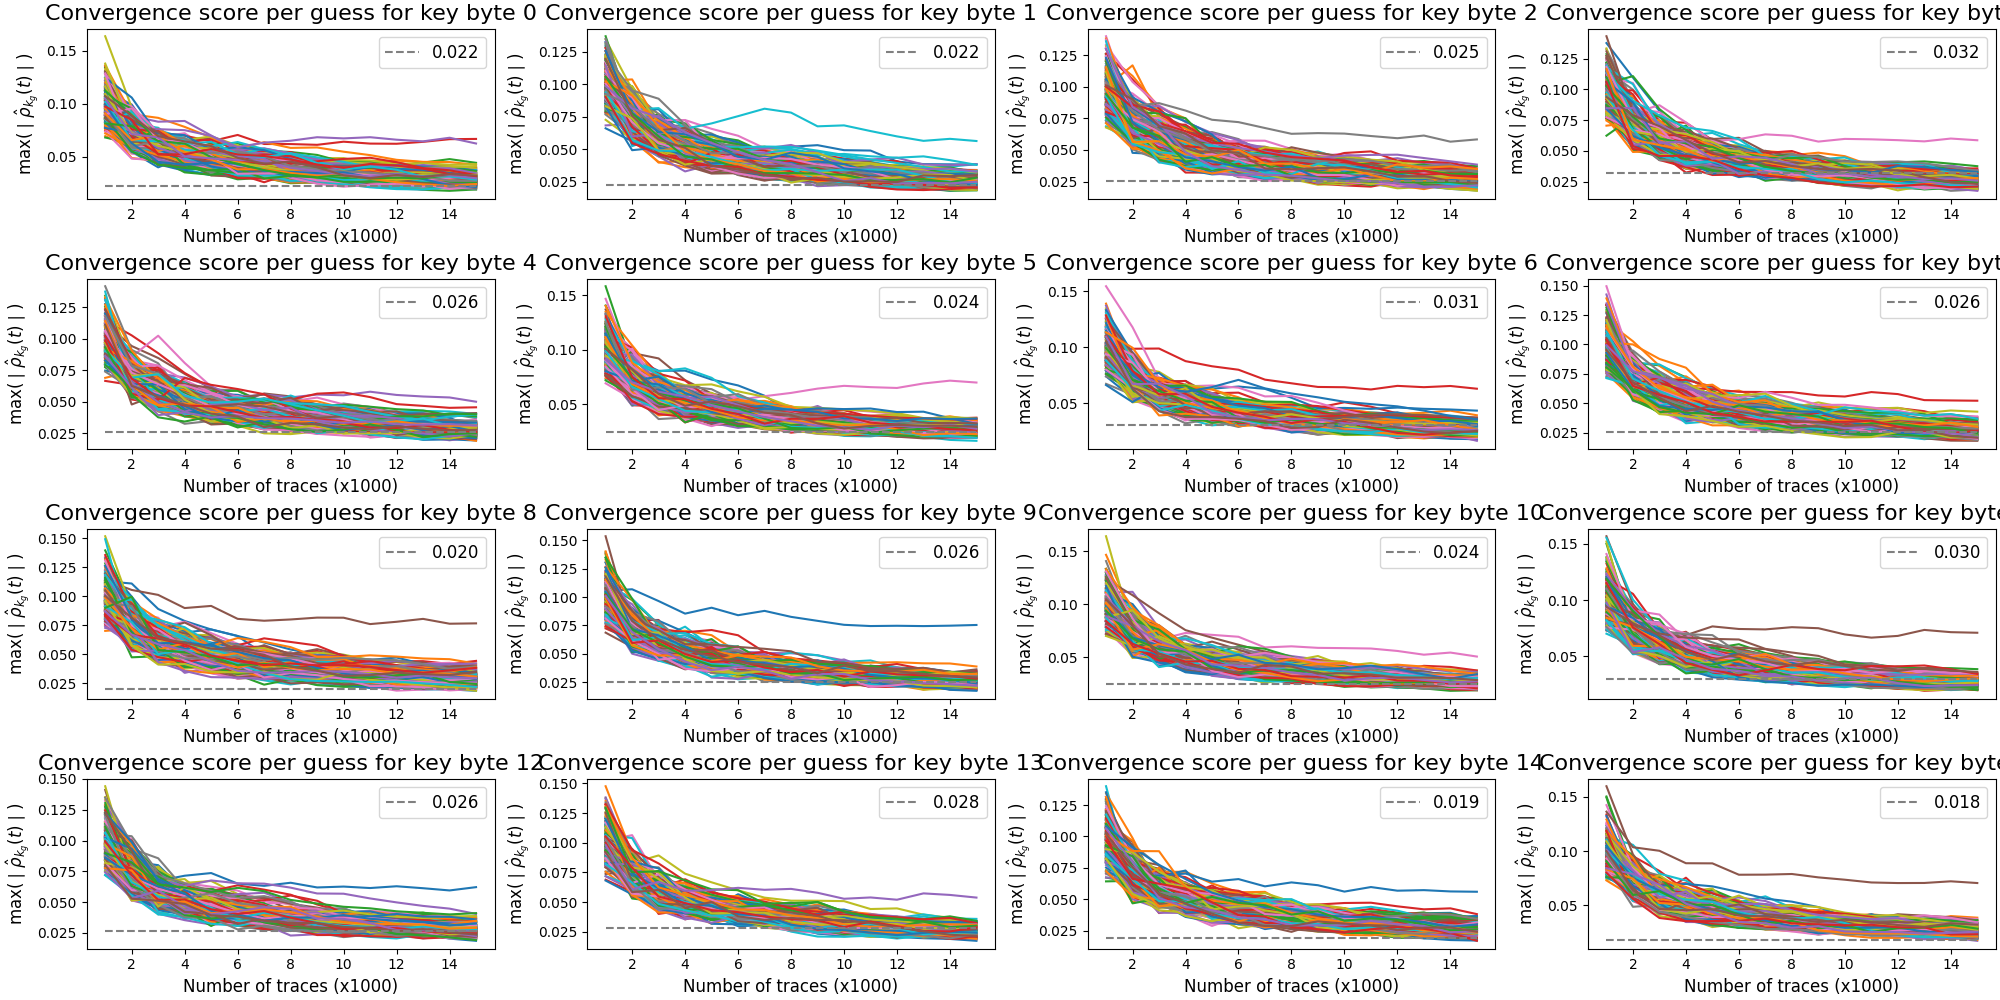

In [ ]:
# PROTECTOR TAB
image_urlbox = widgets.Text(
    description="Image URL:",
    placeholder="URL goes here",
    disabled=False
)

key_combobox = widgets.BoundedIntText(
    value=1,
    min=1,
    max=32,
    step=1,
    description="Key num:",
)

submit_button = widgets.Button(
    description="Encrypt image",
    disabled=False
)

info_from_student = widgets.VBox([
    widgets.HTML("<h2>Image Info</h2>"),
    image_urlbox, 
    key_combobox, 
    submit_button,
])

image_pre = widgets.Image(
    format="png",
    width=256,
    height=256
)

orig_image_pane = widgets.VBox([
    widgets.HTML("<h2>Original Image</h2>"),
    image_pre
])

image_post = widgets.Image(
    format="png",
    width=256,
    height=256
)

download_button = widgets.HTML(
    value="<a>Download encrypted image</a>",
)

encrypted_image_pane = widgets.VBox([
    widgets.HTML("<h2>Encrypted Image</h2>"),
    image_post,
    download_button,
])

def ui_load_image(btn):
    url = image_urlbox.value
    orig_image_array = get_image_from_url(url)
    orig_image_bytes = BytesIO()
    Image.fromarray(orig_image_array, mode="RGB").save(orig_image_bytes, format="png")
    image_pre.value = orig_image_bytes.getbuffer()
    encrypted_image_bytes = encrypt_image(orig_image_array, key_combobox.value)
    image_post.value = encrypted_image_bytes.getbuffer()
    encrypted_image_bytes.seek(0)
    image_post_url = data_url.construct_data_url("image/png", True, encrypted_image_bytes.read())
    image_post_html = f"<a href={str(image_post_url)} download='encrypted.png'>Download encrypted image</a>"
    download_button.value = image_post_html


submit_button.on_click(ui_load_image)

protector_tabs = widgets.HBox([info_from_student, orig_image_pane, encrypted_image_pane])

# ATTACKER TAB
encrypted_img_upload = widgets.FileUpload(
    accept="image/png",
    multiple=False,
    description="Select Encrypted Image",
)

upload_btn = widgets.Button(
    description="Upload Image"
)

upload_pane = widgets.VBox([
    widgets.HTML("<h2>Upload Image</h2>"),
    encrypted_img_upload,
    upload_btn
])

encrypted_img = widgets.Image(
    format="png",
    width=256,
    height=256
)

encrypted_image_pane = widgets.VBox([
    widgets.HTML("<h2>Encrypted Image</h2>"),
    encrypted_img,
])

select_image_tab = widgets.HBox([upload_pane, encrypted_image_pane])

# PLOT TRACES TAB
num_traces_box = widgets.BoundedIntText(
    min=1,
    max=20000,
    step=1,
    description="Num Traces:"
)

selection_fn_dropdown = widgets.Dropdown(
    options=[
        # "first_round_subbytes_out", 
        "delta_last_two_rounds"
    ],
    description="Selection function:"
)

run_attack_btn = widgets.Button(
    description="Run Attack!"
)

traces_plot = widgets.Output()

num_traces_to_plot_box = widgets.BoundedIntText(
    min=1,
    max=20,
    step=1,
    value=3,
    description="Num Traces:"
)

show_traces_btn = widgets.Button(
    description="Plot traces"
)

explore_traces_tab = widgets.HBox([
    widgets.VBox([
        widgets.HBox([num_traces_to_plot_box, show_traces_btn]), 
        traces_plot
    ])
]) 

# ATTACK PARAMETERS/RUN ATTACK PANE
attack_params_pane = widgets.VBox([
    widgets.HTML("<h2>Attack Parameters</h2>"),
    selection_fn_dropdown,
    num_traces_box,
    run_attack_btn
])

attack_progress = widgets.IntProgress(
    value=0,
    min=0,
    max=1,
    description="Attack Progress",
    orientation="horizontal"
)

recovered_key_output: widgets.Output = widgets.Output()

attack_status_pane = widgets.VBox([
    widgets.HTML("<h2>Attack Status</h2>"),
    attack_progress,
    recovered_key_output
])

attack_params_tab = widgets.HBox([attack_params_pane, attack_status_pane])

# CONVERGENCE GRAPHS TAB
convergence_graphs_pane = widgets.Output()

attack_analysis_tab = widgets.VBox([
    widgets.HTML("<h2>Convergence per Key Byte</h2>"),
    convergence_graphs_pane
])


# DECRYPT IMAGE TAB
decrypted_img = widgets.Image(
    format="png",
    width=256,
    height=256
)

decrypt_image_btn = widgets.Button(
    description="Decrypt Image",
    disabled=True
)

decrypted_image_pane = widgets.VBox([
    widgets.HTML("<h2>Decrypted Image</h2>"),
    decrypted_img,
    recovered_key_output,
    decrypt_image_btn
])

decrypt_image_tab = widgets.HBox([encrypted_image_pane, decrypted_image_pane])

encrypted_image_array = None
ths = None
key_idx = None
recovered_key = None

def ui_upload_encrypted_image(btn):
    global ths
    global key_idx
    global encrypted_image_array
    uploaded_file = encrypted_img_upload.value[0]
    encrypted_img.value = uploaded_file.content
    decrypted_img.value = bytes()
    decrypt_image_btn.disabled = True
    encrypted_image_array, key_idx = load_encrypted_image(BytesIO(uploaded_file.content))
    ths = load_ths(key_idx)
    display(encrypted_image_array.shape)
    display(key_idx)

upload_btn.on_click(ui_upload_encrypted_image)

def ui_show_traces(btn):
    traces_plot.clear_output()
    with traces_plot:
        plot_traces(ths, num_traces_to_plot_box.value, DEBUG=False)

show_traces_btn.on_click(ui_show_traces)

def ui_run_sca(btn):
    global recovered_key
    # Run attack, plot resulting convergences
    recovered_key_output.clear_output()
    convergence_graphs_pane.clear_output()
    decrypted_img.value = bytes()
    decrypt_image_btn.disabled = True
    cpa_attack, recovered_sel_fn_output = run_sca(ths, num_traces_box.value, map_str_to_sel_fn(selection_fn_dropdown.value))
    decrypt_image_btn.disabled = False

    recovered_key = convert_expected_to_actual_key(recovered_sel_fn_output, map_str_to_sel_fn(selection_fn_dropdown.value))
    with recovered_key_output:
        display(f"Recovered: {recovered_sel_fn_output.tobytes().hex().upper()}")
        display(f"After inverting selection fn: {recovered_key.tobytes().hex().upper()}")

    with convergence_graphs_pane:
        plot_convergences(cpa_attack, recovered_key)

    attack_progress.value = attack_progress.max
    
run_attack_btn.on_click(ui_run_sca)

def ui_decrypt_image(btn):
    global encrypted_image_array
    global recovered_key
    decrypted_image = decrypt_image(encrypted_image_array, recovered_key)
    decrypted_img.value = decrypted_image.getbuffer()

decrypt_image_btn.on_click(ui_decrypt_image)

attacker_tabs = widgets.Tab(
    children=[select_image_tab, explore_traces_tab, attack_params_tab, attack_analysis_tab, decrypt_image_tab],
    titles=["Upload image", "Explore Traces", "Attack Setup", "Attack Analysis", "Decrypt Image"]
)

widgets.Tab(
    children=[protector_tabs, attacker_tabs],
    titles=["Encryption", "Attack"]
)

In [ ]:
0000000000000003243F6A8885A308D3
0000000000000003243F6A8885A308D3
0B3066970B3066942F0F0C1CAAAC04CF
98C2EC3B93F28AAFBCFD86B31651827C
4DD1FC7CDE2376D362DEF060748F721C
369160EEE8B2163D8A6CE65DFEE39441
37B3E355DF01F568556D1335AB8E8774
0EA47137D1A5845F84C8976A2F46101E
146E0322C5CB877D410310176E450009
FA0D02BD3FC685C07EC595D7108095DE
2C271F7713E19AB76D240F607DA49ABE
539FB188407E2B3F2D5A245F50FEBEE1

In [18]:
orig_shape = encrypted_image_array.shape

# Flatten image to 1D bytes
encrypted_img_flat = encrypted_image_array.reshape(-1).astype(np.uint8)

# Check AES block alignment
if encrypted_img_flat.size % 16 != 0:
    raise ValueError(f"Image byte length {encrypted_img_flat.size} is not divisible by 16.")

# Reshape into N x 16 AES blocks
encrypted_blocks = encrypted_img_flat.reshape(-1, 16)

# Decrypt the blocks
decrypted_blocks = aes.decrypt(encrypted_blocks, recovered_key)

# Reshape the decrypted image blocks
decrypted_flat = decrypted_blocks.reshape(-1)
decrypted_img_array = decrypted_flat.reshape(orig_shape)

# Display image
plt.figure(figsize=(4, 4))
plt.imshow(decrypted_img_array)
plt.axis("off")
plt.show()


AttributeError: 'NoneType' object has no attribute 'shape'